### This notebook loads the t-contrast maps from the HR*CRF regressor and plot them

In [13]:
import numpy as np
import nibabel as nib
import nitools as nt
import nilearn.image as image
from nilearn import plotting
import matplotlib.pyplot as plt
import os

In [17]:
hrcrf_path = '/cifs/diedrichsen/data/Cerebellum/Social/data/GLM_physio/glm_task1_retro0_hrcrf1_hr0'
hr_path = '/cifs/diedrichsen/data/Cerebellum/Social/data/GLM_physio/glm_task1_retro0_hrcrf0_hr1'
anat_path = '/cifs/diedrichsen/data/Cerebellum/Social/data/anatomicals/'
subj_list = ['sub-05', 'sub-07', 'sub-08', 'sub-09', 'sub-11', 'sub-12', 'sub-13', 'sub-16', 
'sub-17', 'sub-18', 'sub-19', 'sub-20', 'sub-21', 'sub-22', 'sub-25', 'sub-27']

#### T-contrast maps of HR*CRF when task+HR\*CRF regressors in GLM

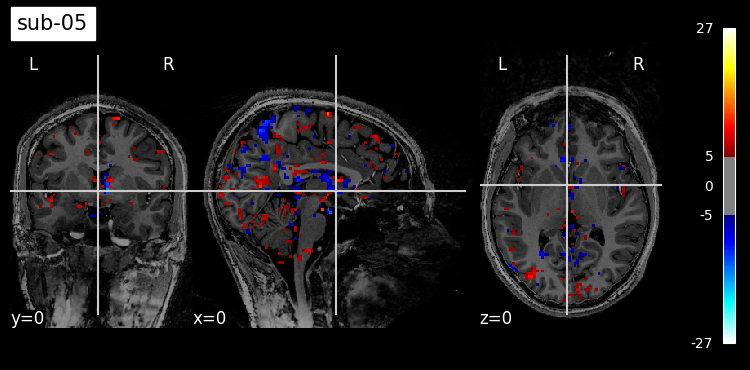

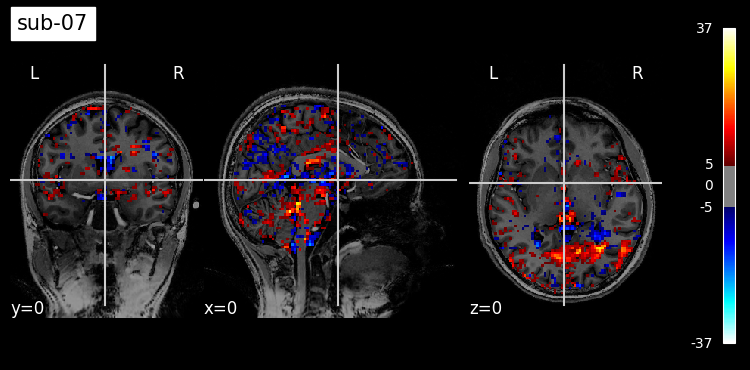

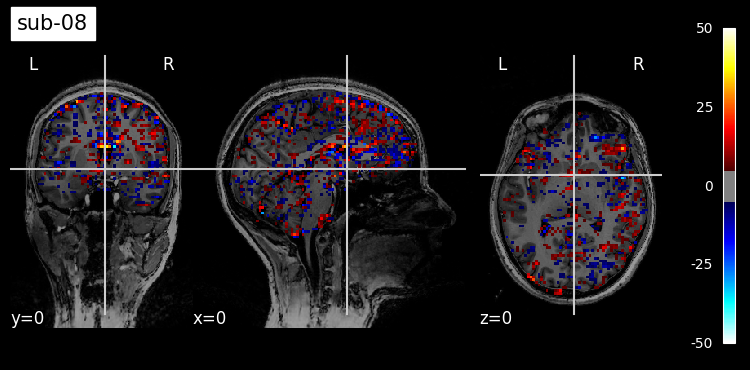

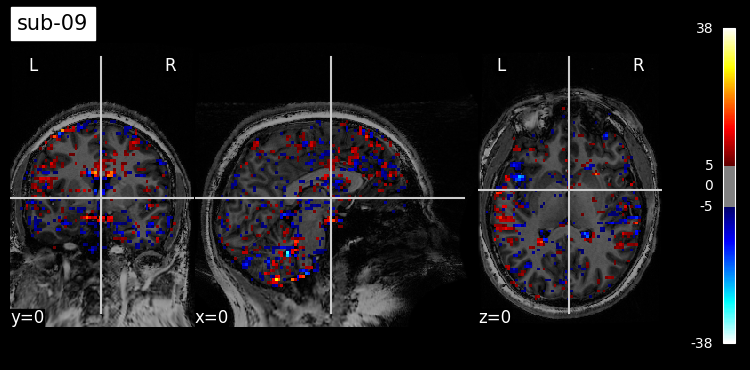

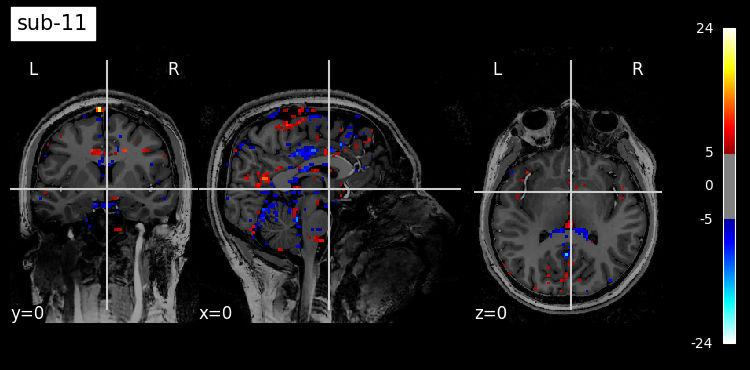

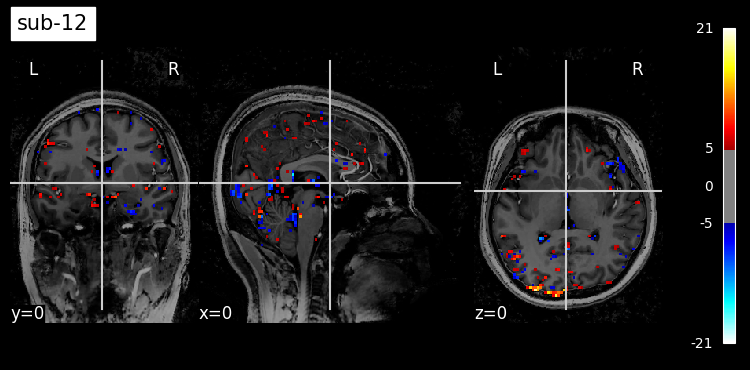

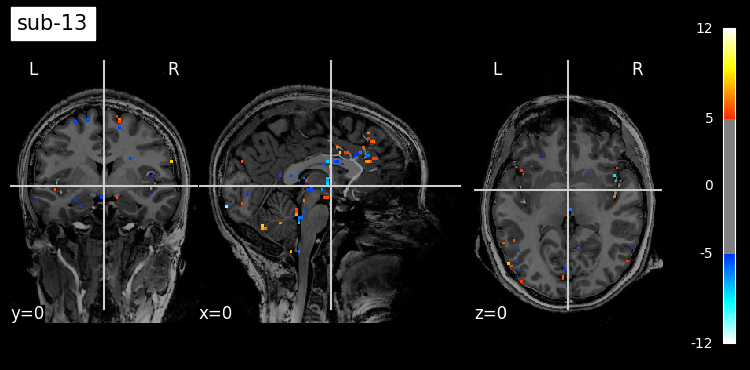

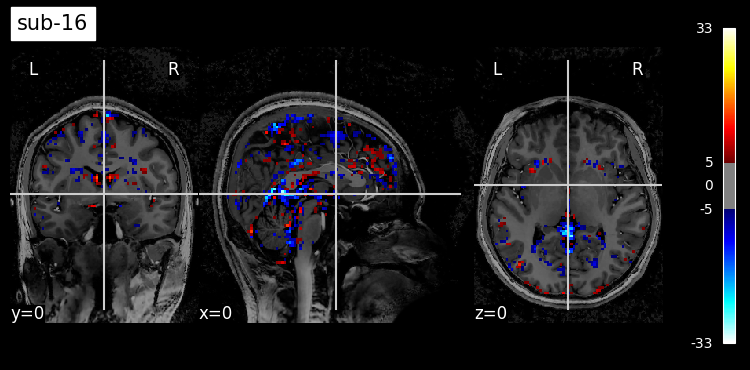

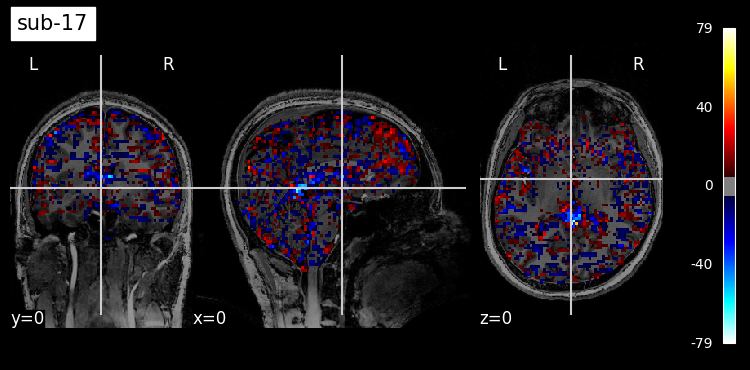

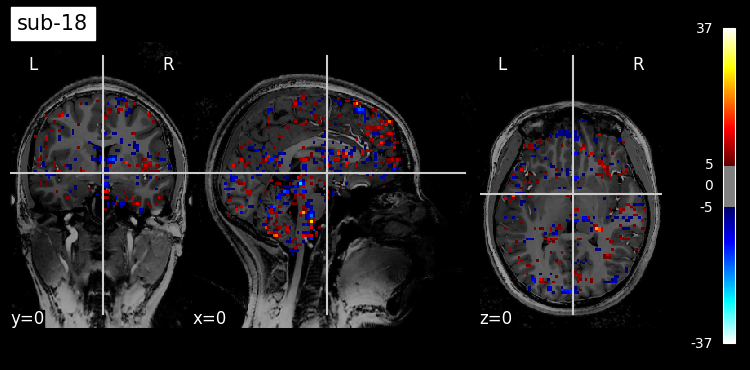

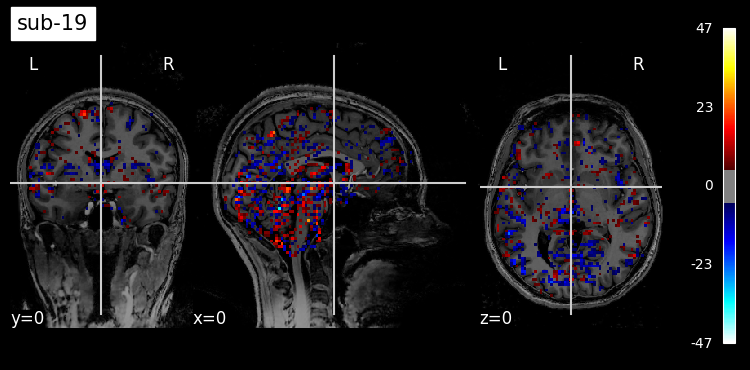

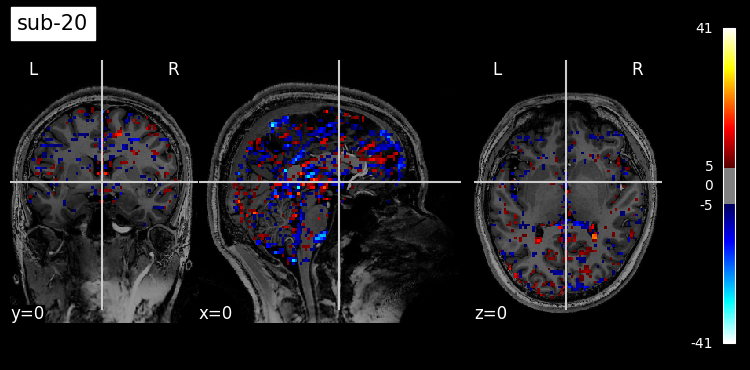

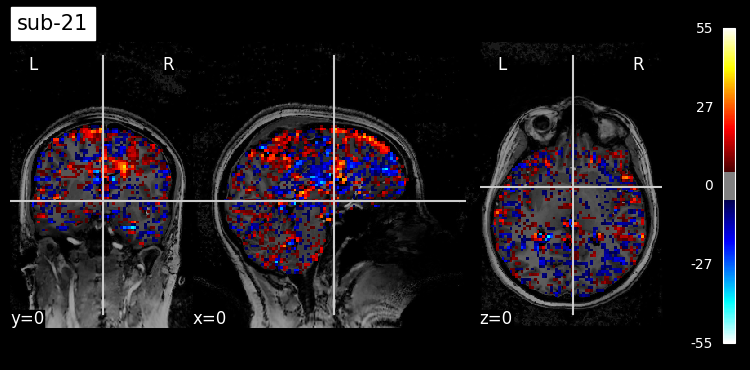

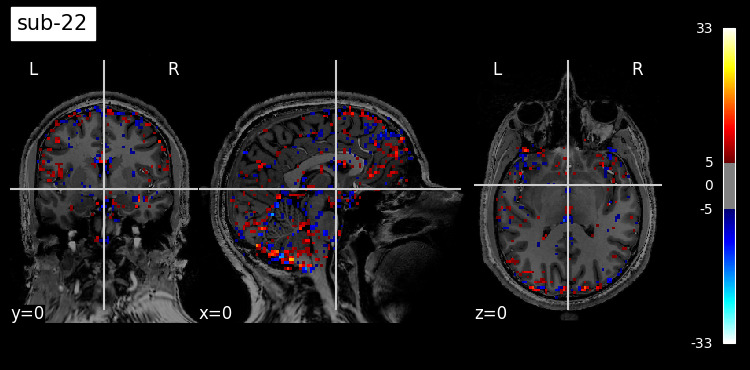

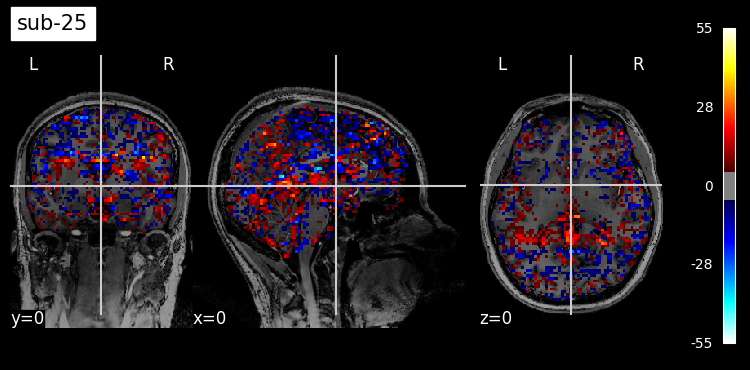

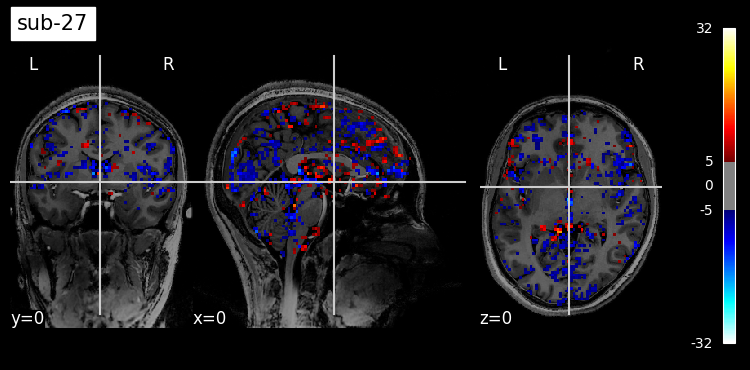

In [ ]:
for sub in subj_list:
    anat_img = nib.load(f'{anat_path}/{sub}/anatomical.nii')
    
    display = plotting.plot_stat_map(
            f'{hrcrf_path}/{sub}/spmT_0001.nii',
            bg_img=anat_img,
            display_mode="ortho",
            cut_coords=(0,0,0),
            threshold=5.0,
            colorbar=True,
            title=f"{sub}"
        )
    plt.show()

### Transform contrast maps from individual space to MNI

In [ ]:
for sub in subj_list:
    # file paths
    con_file = f'{hrcrf_path}/{sub}/con_0001.nii'
    mask_file = f'{hrcrf_path}/{sub}/mask.nii'
    def_file = f'{anat_path}/{sub}/y_anatomical.nii'

    # load files
    con_img = nib.load(con_file)
    mask_img = nib.load(mask_file)
    mask_data = mask_img.get_fdata()
    def_img = nib.load(def_file)

    # smooth image
    smoothed_img = image.smooth_img(con_img, fwhm=4)
    smoothed_data = smoothed_img.get_fdata()

    # apply mask
    masked_data = smoothed_data * (mask_data > 0)
    masked_img = nib.Nifti1Image(masked_data, con_img.affine, con_img.header)

    # deform image
    wcon_file = nt.deform_image(masked_img, def_img, interpolation=1)
    wcon_path = os.path.join(hrcrf_path, f'{sub}/wcon_0001.nii')
    nib.save(wcon_file, wcon_path)

    # deform mask
    wmask_file = nt.deform_image(mask_img, def_img, interpolation=0)
    wmask_path = os.path.join(hrcrf_path, f'{sub}/wmask.nii')
    nib.save(wmask_file, wmask_path)

    # avg wmask
    wmask_data = wmask_file.get_fdata()
    if sub == subj_list[0]:
        all_wmask_data = np.zeros(wmask_data.shape + (len(subj_list),))
    all_wmask_data[..., s] = wmask_data
    
# save avg wmask
mean_wmask_data = np.nanmean(all_wmask_data, axis=3)
mean_wmask_img = nib.Nifti1Image(mean_wmask_data, wmask_file.affine, wmask_file.header)
nib.save(mean_wmask_img, os.path.join(hrcrf_path, 'group/mean_wmask.nii'))

/home/UWO/ashahb7/Documents/cortico/lib/python3.8/site-packages/nilearn/plotting/img_plotting.py:1317: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  safe_get_data(stat_map_img, ensure_finite=True),


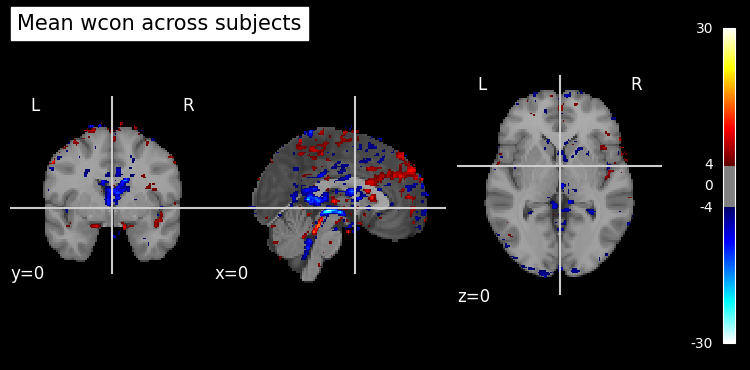

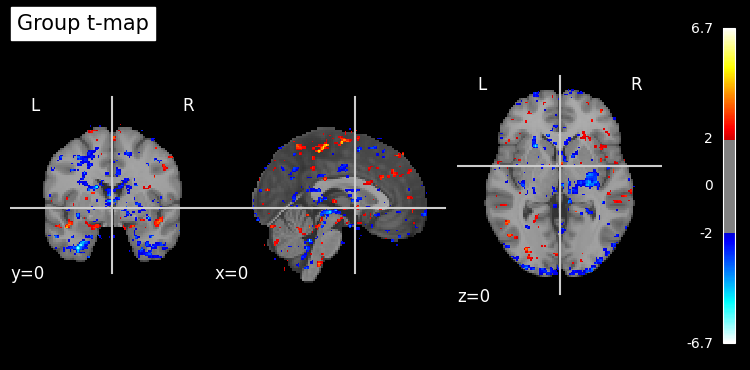

In [20]:
# Plot the mean wcon image and t-test
display = plotting.plot_stat_map(
        os.path.join(hrcrf_path, 'group/con_0001.nii'),
        # bg_img=None,
        display_mode="ortho",
        cut_coords=(0,0,0),
        threshold=4,
        colorbar=True,
        title="Mean wcon across subjects",
        black_bg=True
    )
plt.show()

display = plotting.plot_stat_map(
        os.path.join(hrcrf_path, 'group/spmT_0001.nii'),
        # bg_img=None,
        display_mode="ortho",
        cut_coords=(0,0,0),
        threshold=2,
        colorbar=True,
        title="Group t-map",
        black_bg=True
    )
plt.show()

#### T-contrast maps of HR*CRF when task+HR\*CRF regressors in GLM

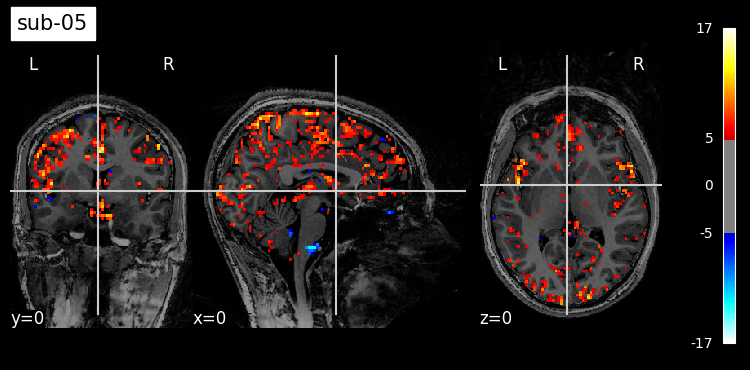

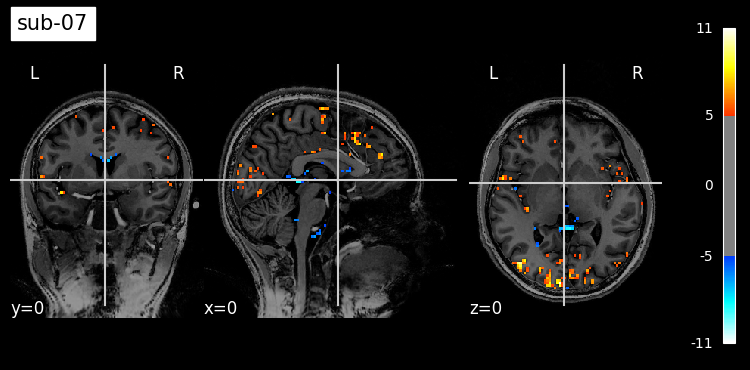

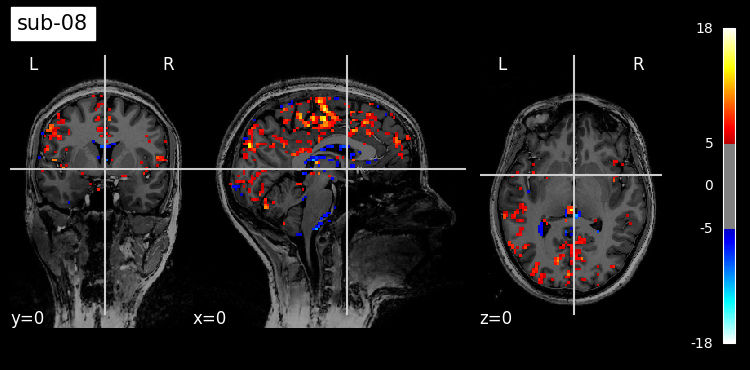

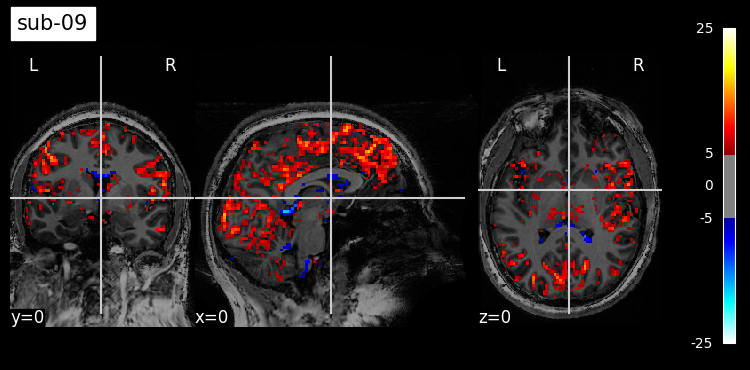

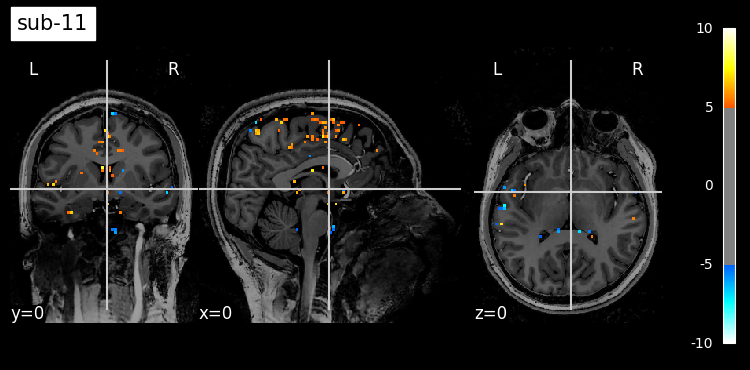

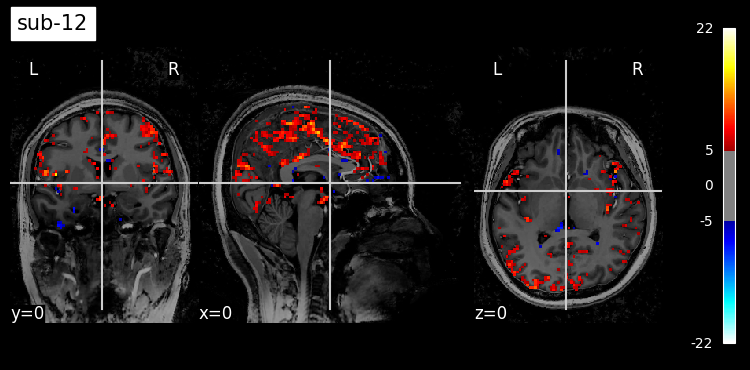

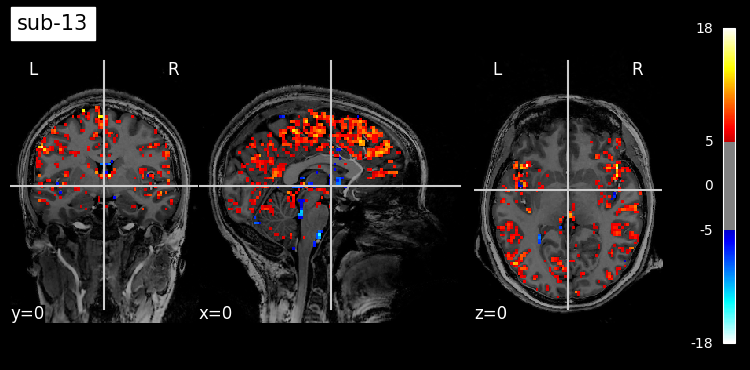

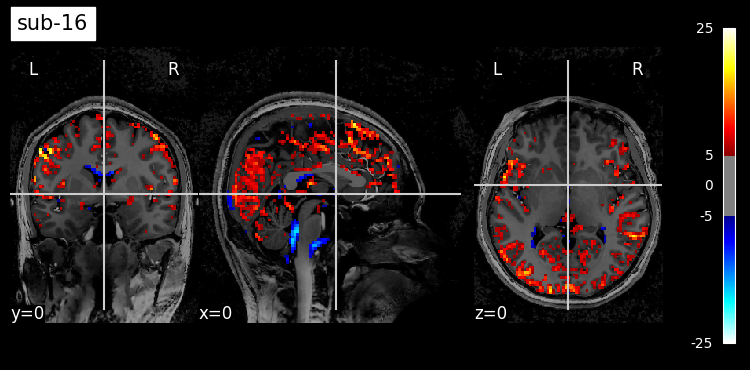

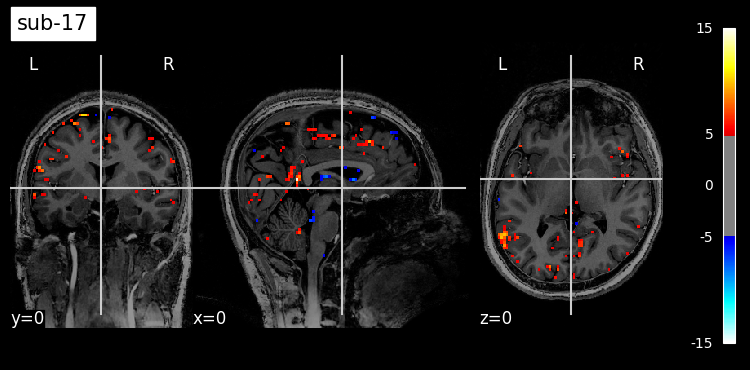

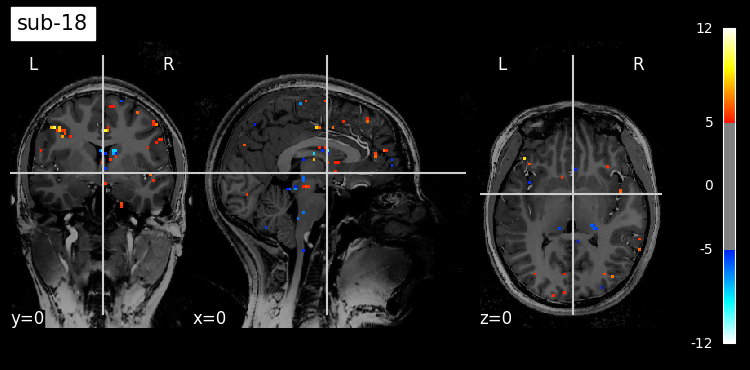

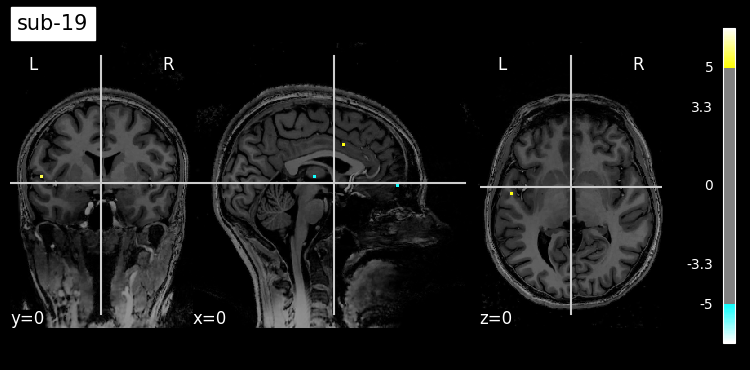

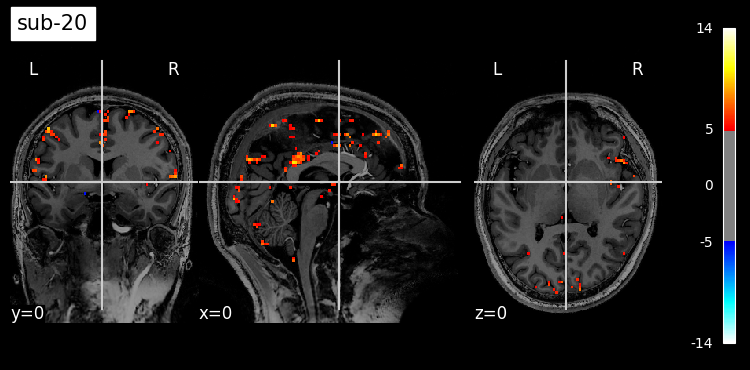

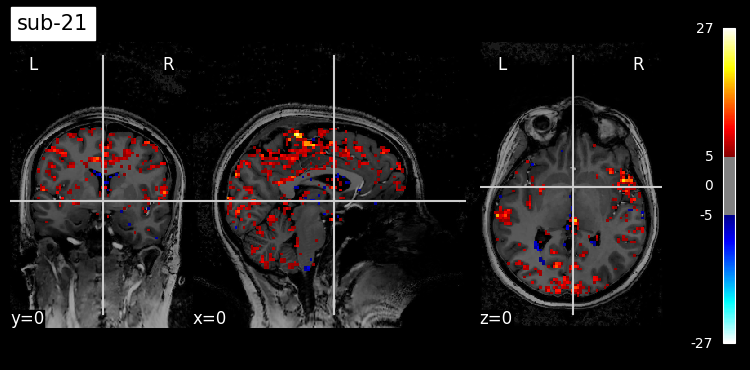

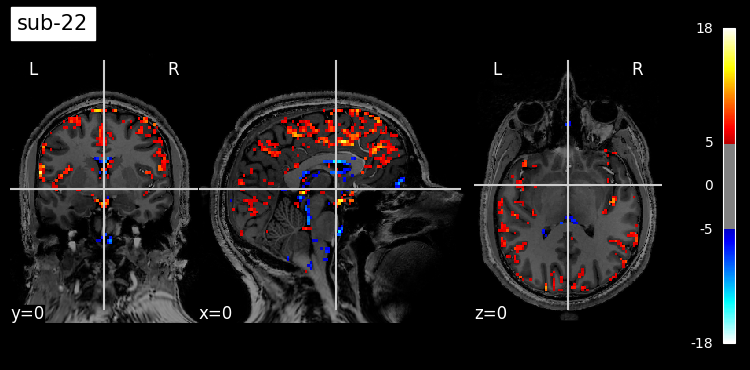

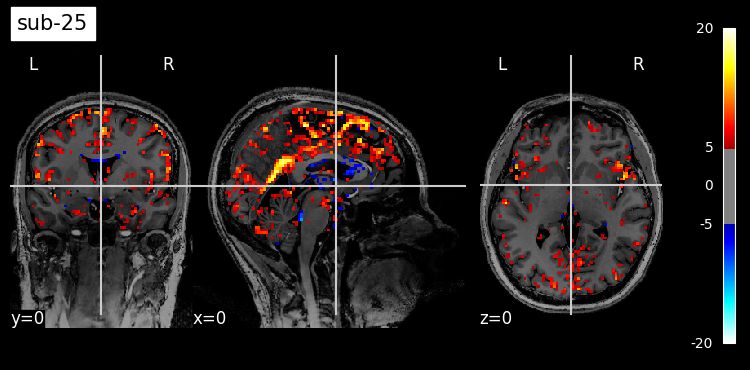

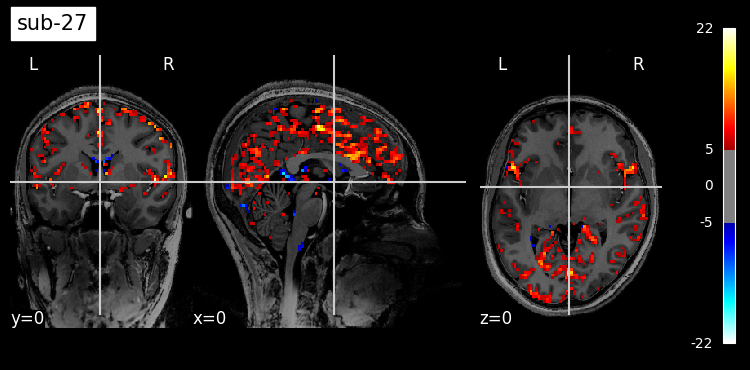

In [ ]:
for sub in subj_list:
    anat_img = nib.load(f'{anat_path}/{sub}/anatomical.nii')
    
    display = plotting.plot_stat_map(
            f'{hr_path}/{sub}/spmT_0001.nii',
            bg_img=anat_img,
            display_mode="ortho",
            cut_coords=(0,0,0),
            threshold=5.0,
            colorbar=True,
            title=f"{sub}"
        )
    plt.show()

In [22]:
for s, sub in enumerate(subj_list):
    # file paths
    con_file = f'{hr_path}/{sub}/con_0001.nii'
    mask_file = f'{hr_path}/{sub}/mask.nii'
    def_file = f'{anat_path}/{sub}/y_anatomical.nii'

    # load files
    con_img = nib.load(con_file)
    mask_img = nib.load(mask_file)
    mask_data = mask_img.get_fdata()
    def_img = nib.load(def_file)

    # smooth image
    smoothed_img = image.smooth_img(con_img, fwhm=4)
    smoothed_data = smoothed_img.get_fdata()

    # apply mask
    masked_data = smoothed_data * (mask_data > 0)
    masked_img = nib.Nifti1Image(masked_data, con_img.affine, con_img.header)

    # deform image
    wcon_file = nt.deform_image(masked_img, def_img, interpolation=1)
    wcon_path = os.path.join(hr_path, f'{sub}/wcon_0001.nii')
    nib.save(wcon_file, wcon_path)

    # deform mask
    wmask_file = nt.deform_image(mask_img, def_img, interpolation=0)
    wmask_path = os.path.join(hr_path, f'{sub}/wmask.nii')
    nib.save(wmask_file, wmask_path)

    # avg wmask
    wmask_data = wmask_file.get_fdata()
    if sub == subj_list[0]:
        all_wmask_data = np.zeros(wmask_data.shape + (len(subj_list),))
    all_wmask_data[..., s] = wmask_data
    
# save avg wmask
mean_wmask_data = np.nanmean(all_wmask_data, axis=3)
mean_wmask_img = nib.Nifti1Image(mean_wmask_data, wmask_file.affine, wmask_file.header)
nib.save(mean_wmask_img, os.path.join(hr_path, 'group/mean_wmask.nii'))


/tmp/ipykernel_750598/3362550262.py:38: RuntimeWarning: Mean of empty slice
  mean_wmask_data = np.nanmean(all_wmask_data, axis=3)


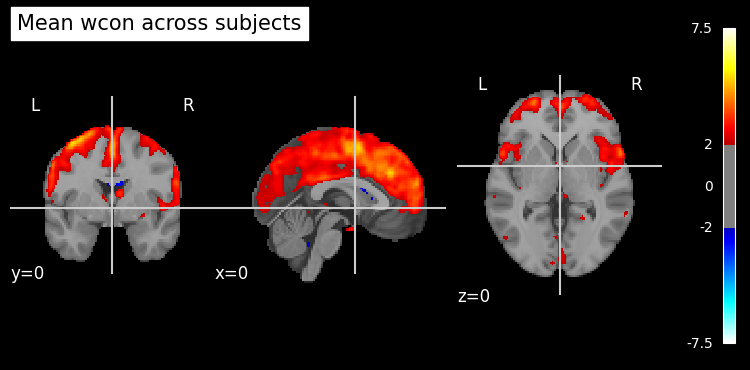

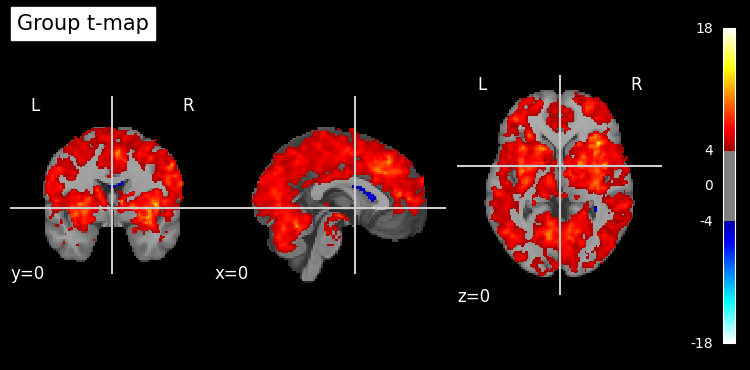

In [26]:
# Plot the mean wcon image and t-test
display = plotting.plot_stat_map(
        os.path.join(hr_path, 'group/con_0001.nii'),
        # bg_img=None,
        display_mode="ortho",
        cut_coords=(0,0,0),
        threshold=2,
        colorbar=True,
        title="Mean wcon across subjects",
        black_bg=True
    )
plt.show()

display = plotting.plot_stat_map(
        os.path.join(hr_path, 'group/spmT_0001.nii'),
        # bg_img=None,
        display_mode="ortho",
        cut_coords=(0,0,0),
        threshold=4,
        colorbar=True,
        title="Group t-map",
        black_bg=True
    )
plt.show()